In [ ]:
%pip install kneed
%pip install kneebow

In [ ]:
import pandas as pd
import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import folium
import itertools
from bs4 import BeautifulSoup
import requests
from requests import get
import time
from datetime import datetime
from random import seed
from random import random
from random import randint
import re
from re import search
import gc
from yellowbrick.cluster import KElbowVisualizer
from kneebow.rotor import Rotor
from random import sample
from numpy.random import uniform
from math import isnan

In [ ]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ejecutando en entorno local o sin Google Colab.')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from pathlib import Path

POSSIBLE_PATHS = [
    Path('../../data/raw/proyectos_la_victoria_sep25.csv'),
    Path('data/raw/proyectos_la_victoria_sep25.csv'),
    Path('/content/drive/My Drive/Colab Notebooks/proyectos_la_victoria_sep25.csv'),
    Path('proyectos_la_victoria_sep25.csv'),
]

file_path = None
for p in POSSIBLE_PATHS:
    if p.exists():
        file_path = str(p)
        break

if file_path is None:
    file_path = '/content/drive/My Drive/Colab Notebooks/proyectos_la_victoria_sep25.csv'

try:
    df = pd.read_csv(file_path, encoding='latin1')
    print(f'Archivo cargado exitosamente desde: {file_path}')
    display(df.head())
except FileNotFoundError:
    print(f'Error: El archivo no se encontró en la ruta especificada: {file_path}')
except Exception as e:
    print(f'Ocurrió un error al cargar el archivo: {e}')


Archivo cargado exitosamente:


,Inmobiliaria,Proyecto,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,activo
0,Abril Grupo Inmobiliario,Pino,-77.016833,-12.089007,663,34,1.8,52.0,"311,462","6,063",1
1,Abril Grupo Inmobiliario,Sauco,-77.019395,-12.089912,628,33,2.0,58.0,"378,385","6,480",1
2,Arteco,Midtown,-77.011280,-12.087771,94,14,2.3,62.0,"420,749","6,952",1
3,Balance Grupo Inmobiliario,HERCELLES,-77.022909,-12.086823,71,8,2.1,61.0,"427,072","7,178",1
4,Casaideal Inmobiliaria,VÖN,-77.018236,-12.088916,297,177,2.1,51.0,"343,696","6,731",1


In [ ]:
df_activos = df[df['activo'] == 1].copy() # Create a copy to avoid SettingWithCopyWarning
df_activos = df_activos.reset_index(drop=True)
df_activos

,Inmobiliaria,Proyecto,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,activo
0,Abril Grupo Inmobiliario,Pino,-77.016833,-12.089007,663,34,1.8,52.0,"311,462","6,063",1
1,Abril Grupo Inmobiliario,Sauco,-77.019395,-12.089912,628,33,2.0,58.0,"378,385","6,480",1
2,Arteco,Midtown,-77.011280,-12.087771,94,14,2.3,62.0,"420,749","6,952",1
3,Balance Grupo Inmobiliario,HERCELLES,-77.022909,-12.086823,71,8,2.1,61.0,"427,072","7,178",1
4,Casaideal Inmobiliaria,VÖN,-77.018236,-12.088916,297,177,2.1,51.0,"343,696","6,731",1
5,Gdc Inmobiliaria,Park Prado,-77.020130,-12.090106,384,33,2.3,61.0,"466,242","7,705",1
6,Ghs Constructora,Catalina View,-77.021394,-12.084095,63,17,2.4,62.0,"407,722","6,540",1
7,Grupo Lar,Elant | Fase 2,-77.025818,-12.082178,165,28,2.3,59.0,"419,186","7,204",1
8,Grupo Lar,Elant | Fase 3,-77.025835,-12.082083,187,28,1.9,53.0,"377,000","7,144",1
9,Grupo Lar,Hara | Etapa 5,-77.012019,-12.081167,286,25,2.0,53.8,"407,725.6","7,803.5",1


In [ ]:
# Select relevant features for clustering
# I'm selecting numerical columns that seem relevant based on the head of the dataframe.
# You might want to adjust this list based on your understanding of the data.
col_names = ['cant und totales', 'cnat de pisos', 'prom_p dorm',
                           'prom_p area', 'prom_p ticket',
                           'prom_p pxm2', 'Longitud', 'Latitud']

features = df_activos[col_names].copy() # Create a copy to avoid SettingWithCopyWarning

# Convert columns with commas to numeric
for col in ['prom_p ticket', 'prom_p pxm2']:
    features[col] = features[col].astype(str).str.replace(',', '', regex=False)
    features[col] = pd.to_numeric(features[col], errors='coerce')


scaler = StandardScaler().fit(features.values)
features = scaler.transform(features.values)
scaled_features = pd.DataFrame(features, index=df_activos.index, columns=col_names)
display(scaled_features.head())

,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,Longitud,Latitud
0,2.751089,0.214563,-0.892554,-0.919136,-1.506635,-1.344243,0.396695,-0.874005
1,2.536400,0.180141,-0.277000,-0.186432,-0.415951,-0.669357,-0.080364,-1.083663
2,-0.739144,-0.473874,0.646332,0.302037,0.274480,0.094543,1.430667,-0.587672
3,-0.880226,-0.680405,0.030778,0.179919,0.377530,0.460309,-0.734625,-0.367873
4,0.506053,5.136887,0.030778,-1.041253,-0.981299,-0.263130,0.135600,-0.852739


Text(0, 0.5, 'Inertia')

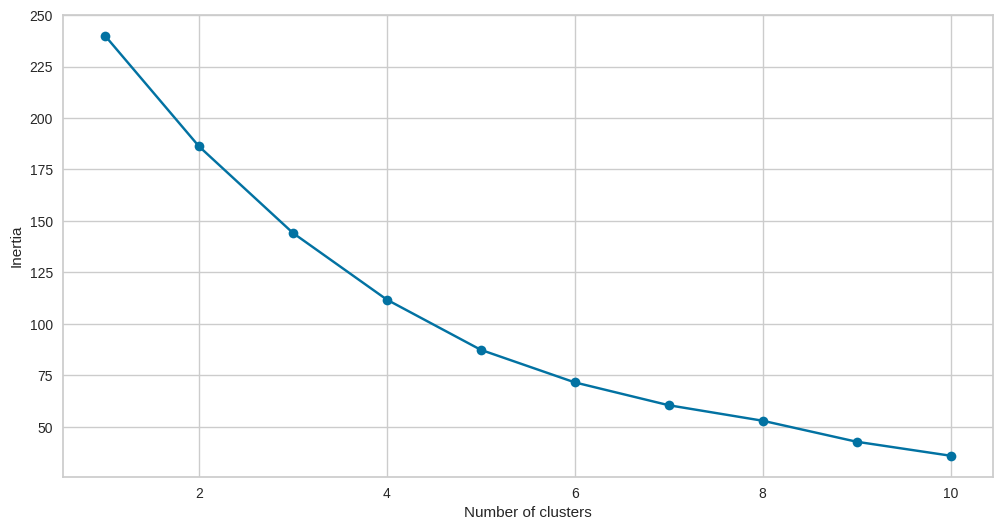

In [ ]:
SSE = []

for cluster in range(1, 11):
    kmeans = KMeans(n_clusters=cluster, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(scaled_features)
    SSE.append(kmeans.inertia_)

frame = pd.DataFrame({'Cluster':range(1,11), 'SSE':SSE})
plt.figure(figsize=(12,6))
plt.plot(frame['Cluster'], frame['SSE'], marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

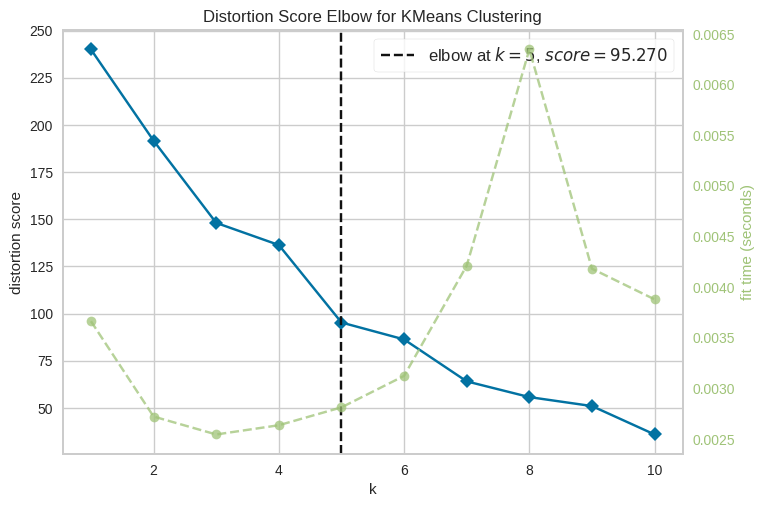

np.int64(5)

In [ ]:
kmeans = KMeans()
elbow = KElbowVisualizer(kmeans, k=(1,11))
elbow.fit(scaled_features)
elbow.show(block=True)

elbow.elbow_value_

In [ ]:
kmeans = KMeans(n_clusters= 4, init='k-means++')
kmeans.fit(scaled_features)

print(silhouette_score(scaled_features, kmeans.labels_, metric='euclidean'))

0.24691065668265538


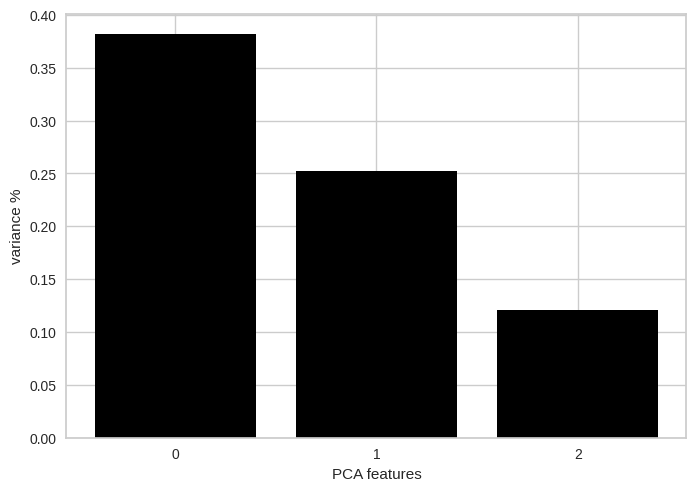

In [ ]:
pca = PCA(n_components=3)
principalComponents = pca.fit_transform(scaled_features)

features = range(pca.n_components_)
plt.bar(features, pca.explained_variance_ratio_, color='black')
plt.xlabel('PCA features')
plt.ylabel('variance %')
plt.xticks(features)

PCA_components = pd.DataFrame(principalComponents)

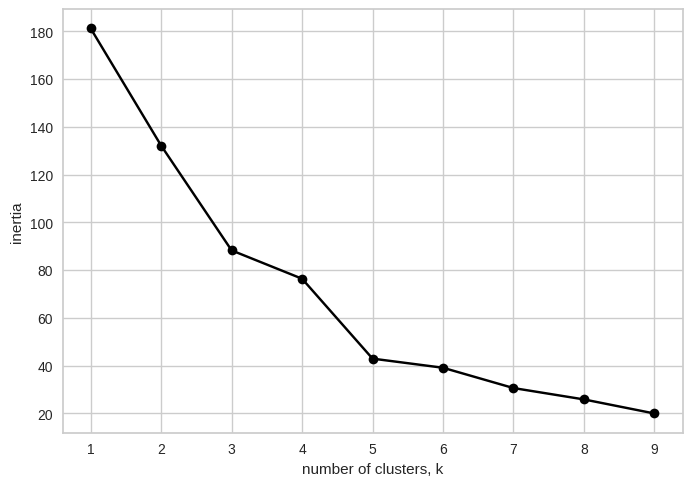

In [ ]:
ks = range(1,10)
inertias = []

for k in ks:
    model = KMeans(n_clusters=k)
    model.fit(PCA_components.iloc[:,:5])
    inertias.append(model.inertia_)

plt.plot(ks, inertias, '-o', color='black')
plt.xlabel('number of clusters, k')
plt.ylabel('inertia')
plt.xticks(ks)
plt.show()

In [ ]:
n_clusters = 5
model = KMeans(n_clusters=n_clusters)
model.fit(PCA_components.iloc[:,:5])

print(silhouette_score(PCA_components.iloc[:,:5], model.labels_, metric='euclidean'))

0.3526384201603312


In [ ]:
pred = model.predict(PCA_components.iloc[:,:5])
df_activos['cluster'] = pred
df_activos

,Inmobiliaria,Proyecto,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,activo,cluster
0,Abril Grupo Inmobiliario,Pino,-77.016833,-12.089007,663,34,1.8,52.0,"311,462","6,063",1,3
1,Abril Grupo Inmobiliario,Sauco,-77.019395,-12.089912,628,33,2.0,58.0,"378,385","6,480",1,3
2,Arteco,Midtown,-77.011280,-12.087771,94,14,2.3,62.0,"420,749","6,952",1,0
3,Balance Grupo Inmobiliario,HERCELLES,-77.022909,-12.086823,71,8,2.1,61.0,"427,072","7,178",1,4
4,Casaideal Inmobiliaria,VÖN,-77.018236,-12.088916,297,177,2.1,51.0,"343,696","6,731",1,3
5,Gdc Inmobiliaria,Park Prado,-77.020130,-12.090106,384,33,2.3,61.0,"466,242","7,705",1,0
6,Ghs Constructora,Catalina View,-77.021394,-12.084095,63,17,2.4,62.0,"407,722","6,540",1,4
7,Grupo Lar,Elant | Fase 2,-77.025818,-12.082178,165,28,2.3,59.0,"419,186","7,204",1,4
8,Grupo Lar,Elant | Fase 3,-77.025835,-12.082083,187,28,1.9,53.0,"377,000","7,144",1,4
14,Grupo Lar,Hara | Etapa 5,-77.012019,-12.081167,286,25,2.0,53.8,"407,725.6","7,803.5",1,0


In [ ]:
# Exportar dataset con clusters asignados
output_dir = Path('../../data/processed')
if not output_dir.exists():
    output_dir = Path('.')
save_csv_path = output_dir / f'df_activos_cluster_{n_clusters}_la_victoria.csv'
df_activos.to_csv(save_csv_path, index=False)
print(f'Guardado en: {save_csv_path}')


In [ ]:
# Confirmación de exportación
print(f'DataFrame guardado exitosamente con {len(df_activos)} proyectos y {n_clusters} clusters.')


DataFrame guardado exitosamente en: /content/df_activos_cluster_5_la_victoria.csv


In [ ]:
lat_loc = df_activos['Latitud'].mean()
long_loc = df_activos['Longitud'].mean()

In [ ]:
# Create a map object of the city of Barcelona
distrito_map= folium.Map(location=[lat_loc, long_loc], zoom_start=14.5)

# Display only accidents where serious injuries where recorded
for lat, lng, label, name in zip(df_activos.Latitud, df_activos.Longitud, df_activos.cluster.astype(str), df_activos.Proyecto):
    if label =='0':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='red',
            fill=True,
            popup=[label,name],
            fill_color='red',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='1':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='green',
            fill=True,
            popup=[label,name],
            fill_color='green',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='2':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='black',
            fill=True,
            popup=[label,name],
            fill_color='black',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='3':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='blue',
            fill=True,
            popup=[label,name],
            fill_color='blue',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='4':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='purple',
            fill=True,
            popup=[label,name],
            fill_color='purple',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='5':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='cyan',
            fill=True,
            popup=[label,name],
            fill_color='cyan',
            fill_opacity=0.6
        ).add_to(distrito_map)

# Show map
distrito_map

In [ ]:
df_activos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 41
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Inmobiliaria      30 non-null     object 
 1   Proyecto          30 non-null     object 
 2   Longitud          30 non-null     float64
 3   Latitud           30 non-null     float64
 4   cant und totales  30 non-null     int64  
 5   cnat de pisos     30 non-null     int64  
 6   prom_p dorm       30 non-null     float64
 7   prom_p area       30 non-null     float64
 8   prom_p ticket     30 non-null     object 
 9   prom_p pxm2       30 non-null     object 
 10  activo            30 non-null     int64  
 11  cluster           30 non-null     int32  
dtypes: float64(4), int32(1), int64(3), object(4)
memory usage: 2.9+ KB


In [ ]:
df_activos_copy = df_activos.copy()
df_activos_copy

,Inmobiliaria,Proyecto,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,activo,cluster
0,Abril Grupo Inmobiliario,Pino,-77.016833,-12.089007,663,34,1.8,52.0,"311,462","6,063",1,3
1,Abril Grupo Inmobiliario,Sauco,-77.019395,-12.089912,628,33,2.0,58.0,"378,385","6,480",1,3
2,Arteco,Midtown,-77.011280,-12.087771,94,14,2.3,62.0,"420,749","6,952",1,0
3,Balance Grupo Inmobiliario,HERCELLES,-77.022909,-12.086823,71,8,2.1,61.0,"427,072","7,178",1,4
4,Casaideal Inmobiliaria,VÖN,-77.018236,-12.088916,297,177,2.1,51.0,"343,696","6,731",1,3
5,Gdc Inmobiliaria,Park Prado,-77.020130,-12.090106,384,33,2.3,61.0,"466,242","7,705",1,0
6,Ghs Constructora,Catalina View,-77.021394,-12.084095,63,17,2.4,62.0,"407,722","6,540",1,4
7,Grupo Lar,Elant | Fase 2,-77.025818,-12.082178,165,28,2.3,59.0,"419,186","7,204",1,4
8,Grupo Lar,Elant | Fase 3,-77.025835,-12.082083,187,28,1.9,53.0,"377,000","7,144",1,4
14,Grupo Lar,Hara | Etapa 5,-77.012019,-12.081167,286,25,2.0,53.8,"407,725.6","7,803.5",1,0


In [ ]:
df_activos_copy['prom_p ticket'] = df_activos_copy['prom_p ticket'].replace('407,725.6', '407,725')

In [ ]:
# Remove commas and convert to numeric first
df_activos_copy['prom_p ticket'] = df_activos_copy['prom_p ticket'].astype(str).str.replace(',', '', regex=False)
df_activos_copy['prom_p pxm2'] = df_activos_copy['prom_p pxm2'].astype(str).str.replace(',', '', regex=False)

# Convert to float first to handle decimals, then to integer
df_activos_copy['prom_p ticket'] = df_activos_copy['prom_p ticket'].astype(float).astype(int)
df_activos_copy['prom_p pxm2'] = df_activos_copy['prom_p pxm2'].astype(float).astype(int)
display(df_activos_copy.head())

,Inmobiliaria,Proyecto,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,activo,cluster
0,Abril Grupo Inmobiliario,Pino,-77.016833,-12.089007,663,34,1.8,52.0,311462,6063,1,3
1,Abril Grupo Inmobiliario,Sauco,-77.019395,-12.089912,628,33,2.0,58.0,378385,6480,1,3
2,Arteco,Midtown,-77.011280,-12.087771,94,14,2.3,62.0,420749,6952,1,0
3,Balance Grupo Inmobiliario,HERCELLES,-77.022909,-12.086823,71,8,2.1,61.0,427072,7178,1,4
4,Casaideal Inmobiliaria,VÖN,-77.018236,-12.088916,297,177,2.1,51.0,343696,6731,1,3


In [ ]:
df_activos_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30 entries, 0 to 41
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Inmobiliaria      30 non-null     object 
 1   Proyecto          30 non-null     object 
 2   Longitud          30 non-null     float64
 3   Latitud           30 non-null     float64
 4   cant und totales  30 non-null     int64  
 5   cnat de pisos     30 non-null     int64  
 6   prom_p dorm       30 non-null     float64
 7   prom_p area       30 non-null     float64
 8   prom_p ticket     30 non-null     int64  
 9   prom_p pxm2       30 non-null     int64  
 10  activo            30 non-null     int64  
 11  cluster           30 non-null     int32  
dtypes: float64(4), int32(1), int64(5), object(2)
memory usage: 2.9+ KB


In [ ]:
df_activos_copy2 = df_activos_copy[col_names + ['cluster']].copy()
avg_df = df_activos_copy2.groupby(['cluster']).mean()
avg_df['prom_p dorm'] = round(avg_df['prom_p dorm'])

# Select only numeric columns before applying map
numeric_cols = avg_df.select_dtypes(include=np.number).columns.tolist()
display(avg_df[numeric_cols].applymap("{0:,.2f}".format)) # Apply formatting only to numeric columns

/tmp/ipython-input-1950871632.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(avg_df[numeric_cols].applymap("{0:,.2f}".format)) # Apply formatting only to numeric columns


,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,Longitud,Latitud
cluster,,,,,,,,
0,242.40,22.60,2.00,56.18,"404,749.10","7,328.30",-77.01,-12.09
1,31.50,9.50,3.00,84.00,"575,625.00","6,970.00",-77.02,-12.08
2,160.00,21.00,2.00,60.00,"333,253.00","5,610.50",-77.03,-12.07
3,495.75,70.25,2.00,52.25,"345,152.75","6,658.25",-77.02,-12.09
4,137.08,22.08,2.00,60.58,"405,946.58","6,810.83",-77.02,-12.08


# Segmentación con LLM

In [ ]:
from sentence_transformers import SentenceTransformer

In [ ]:
df_activos.head()

,Inmobiliaria,Proyecto,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,activo
0,Abril Grupo Inmobiliario,Pino,-77.016833,-12.089007,663,34,1.8,52.0,"311,462","6,063",1
1,Abril Grupo Inmobiliario,Sauco,-77.019395,-12.089912,628,33,2.0,58.0,"378,385","6,480",1
2,Arteco,Midtown,-77.011280,-12.087771,94,14,2.3,62.0,"420,749","6,952",1
3,Balance Grupo Inmobiliario,HERCELLES,-77.022909,-12.086823,71,8,2.1,61.0,"427,072","7,178",1
4,Casaideal Inmobiliaria,VÖN,-77.018236,-12.088916,297,177,2.1,51.0,"343,696","6,731",1


In [ ]:
df_proyecctos_la_victoria = df_activos[['Longitud','Latitud','cant und totales','cnat de pisos','prom_p dorm','prom_p area', 'prom_p ticket', 'prom_p pxm2']].copy()
df_proyecctos_la_victoria.head()

,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2
0,-77.016833,-12.089007,663,34,1.8,52.0,"311,462","6,063"
1,-77.019395,-12.089912,628,33,2.0,58.0,"378,385","6,480"
2,-77.011280,-12.087771,94,14,2.3,62.0,"420,749","6,952"
3,-77.022909,-12.086823,71,8,2.1,61.0,"427,072","7,178"
4,-77.018236,-12.088916,297,177,2.1,51.0,"343,696","6,731"


In [ ]:
embedding_model = SentenceTransformer('thenlper/gte-small')

def crear_texto_clave_valor(row):
    # Usamos un separador claro como " | " o "; "
    texto = (
        #f"Proyecto: {row['Proyecto']} | "
        #f"Inmobiliaria: {row['Inmobiliaria']} | "
        f"Ubicación: {row['Latitud']}, {row['Longitud']} | "
        f"Pisos: {row['cnat de pisos']} | "
        f"Unidades Totales: {row['cant und totales']} | "
        f"Dormitorios prom: {row['prom_p dorm']} | "
        f"Área prom: {row['prom_p area']} | "
        f"Precio m2: {row['prom_p pxm2']}"
    )
    return texto

# Aplicamos
df_proyecctos_la_victoria['texto_para_embedding'] = df_proyecctos_la_victoria.apply(crear_texto_clave_valor, axis=1)

# Verificamos cómo se ve ahora (mucho más conciso)
print("--- Ejemplo de entrada ---")
print(df_proyecctos_la_victoria['texto_para_embedding'].iloc[0])

# Generamos embeddings
embeddings = embedding_model.encode(df_proyecctos_la_victoria['texto_para_embedding'].tolist(), show_progress_bar=True)

--- Ejemplo de entrada ---
Ubicación: -12.0890073, -77.0168333 | Pisos: 34 | Unidades Totales: 663 | Dormitorios prom: 1.8 | Área prom: 52.0 | Precio m2: 6,063


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
embeddings.shape

(30, 384)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# Proyecto de interés
nombre_buscado = 'Elant | Fase 3'

# 1. Definir el índice del proyecto que quieres analizar (tu "Query")
idx_proyecto_objetivo = df_activos.index[df_activos['Proyecto'] == nombre_buscado].tolist()[0]

# Recuperamos datos básicos para mostrar en el título
nombre_objetivo = df_activos.iloc[idx_proyecto_objetivo]['Proyecto']
print(f"Buscando proyectos similares a: {nombre_objetivo}...\n")

# 2. Obtener el vector de ese proyecto específico
# .reshape(1, -1) es necesario porque scikit-learn espera una matriz 2D, no un vector plano
vector_objetivo = embeddings[idx_proyecto_objetivo].reshape(1, -1)

# 3. Calcular la similitud contra TODOS los proyectos
# Esto devuelve una lista de scores (0 a 1)
scores = cosine_similarity(vector_objetivo, embeddings)

# 4. Pegar los scores en el DataFrame para poder ordenar
df_activos['similitud'] = scores[0]

# 5. Ordenar de mayor a menor similitud
# Excluimos el primero (.iloc[1:]) porque el más similar siempre será él mismo (score 1.0)
df_similares = df_activos.sort_values(by='similitud', ascending=False)

# 6. Mostrar el TOP 5
cols_a_mostrar = ['Proyecto', 'Inmobiliaria', 'prom_p ticket', 'prom_p pxm2', 'similitud']
proyectos_competencia = df_similares[cols_a_mostrar].copy()
print(proyectos_competencia[proyectos_competencia['similitud']>0.95]) # Mostramos 6 para ver el mismo y los 5 siguientes

Buscando proyectos similares a: Elant | Fase 3...

                    Proyecto                  Inmobiliaria prom_p ticket  \
8             Elant | Fase 3                     Grupo Lar       377,000   
17          Residencial Real                           Paz       323,224   
19                    STRONG          Pisonay Inmobiliaria       418,457   
28                   TEMPO 2                   Urbana Perú       452,786   
3                  HERCELLES    Balance Grupo Inmobiliario       427,072   
29           C. VILLARÁN 302        V&V Grupo Inmobiliario       428,294   
18  Residencial Real Etapa 2                           Paz       343,282   
12              Catalina Sky                     Grupo T&C       347,068   
6              Catalina View              Ghs Constructora       407,722   
14                   FORTIVA                        Invent       370,997   
25                  AUDACITY                         Senda       388,354   
7             Elant | Fase 2         

In [ ]:
from umap import UMAP

In [ ]:
# we reduce the input embeddings from 384 dimensions to 5 dimensions

umap_model = UMAP(
    n_components=2,
    min_dist = 0.0,
    metric='cosine',
    random_state = 42
)

umap_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
reduced_embeddings = umap_model.fit_transform(embeddings)

In [ ]:
from hdbscan import HDBSCAN

In [ ]:
# we fit the model and extract the clusters

hdbscan_model = HDBSCAN(
    min_cluster_size = 2,
    metric = 'euclidean',
    cluster_selection_method = 'eom'
).fit(reduced_embeddings) # se puede cambiar por reduced_embeddings / embeddings

clusters = hdbscan_model.labels_

#how many clusters did we generate?
len(set(clusters))

6

In [ ]:
clusters

array([ 4, -1,  3, -1, -1,  4, -1,  3, -1,  0,  0,  3,  1, -1,  2,  4,  1,
        1,  1, -1,  4,  1, -1, -1,  2,  2,  0,  0, -1, -1])

In [ ]:
np.where(clusters==0)[0]

array([ 9, 10, 26, 27])

In [ ]:
df_activos.loc[2]

,2
Inmobiliaria,Arteco
Proyecto,Midtown
Longitud,-77.01128
Latitud,-12.087771
cant und totales,94
cnat de pisos,14
prom_p dorm,2.3
prom_p area,62.0
prom_p ticket,"420,749"
prom_p pxm2,"6,952"


In [ ]:
df_proyecctos_la_victoria['texto_para_embedding'][2]

'Ubicación: -12.0877713, -77.0112804 | Pisos: 14 | Unidades Totales: 94 | Dormitorios prom: 2.3 | Área prom: 62.0 | Precio m2: 6,952'

In [ ]:
df_proyecctos_la_victoria.columns

Index(['Longitud', 'Latitud', 'cant und totales', 'cnat de pisos',
       'prom_p dorm', 'prom_p area', 'prom_p ticket', 'prom_p pxm2',
       'texto_para_embedding'],
      dtype='object')

In [ ]:
# print first three documents in cluster 0

cluster = 2

for index in np.where(clusters==cluster)[0]:
  print(df_activos.iloc[int(index)])

Inmobiliaria           Invent
Proyecto              FORTIVA
Longitud           -77.017731
Latitud            -12.088765
cant und totales          182
cnat de pisos              17
prom_p dorm               1.7
prom_p area              51.0
prom_p ticket         370,997
prom_p pxm2             7,325
activo                      1
similitud            0.998015
clusters                    0
Name: 14, dtype: object
Inmobiliaria        Rumi Grupo Inmobiliario
Proyecto                    PIETRA DI PRADO
Longitud                         -77.018473
Latitud                          -12.089499
cant und totales                        203
cnat de pisos                            30
prom_p dorm                             1.9
prom_p area                            62.0
prom_p ticket                       384,960
prom_p pxm2                           6,203
activo                                    1
similitud                           0.99693
clusters                                  0
Name: 24, dtyp

In [ ]:

df_activos['clusters'] = clusters
df_activos.head(5)

,Inmobiliaria,Proyecto,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,prom_p ticket,prom_p pxm2,activo,similitud,clusters
0,Abril Grupo Inmobiliario,Pino,-77.016833,-12.089007,663,34,1.8,52.0,"311,462","6,063",1,0.997810,4
1,Abril Grupo Inmobiliario,Sauco,-77.019395,-12.089912,628,33,2.0,58.0,"378,385","6,480",1,0.997939,-1
2,Arteco,Midtown,-77.011280,-12.087771,94,14,2.3,62.0,"420,749","6,952",1,0.997534,3
3,Balance Grupo Inmobiliario,HERCELLES,-77.022909,-12.086823,71,8,2.1,61.0,"427,072","7,178",1,0.998229,-1
4,Casaideal Inmobiliaria,VÖN,-77.018236,-12.088916,297,177,2.1,51.0,"343,696","6,731",1,0.997123,-1


In [ ]:


import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
lat_loc = df_activos['Latitud'].mean()
long_loc = df_activos['Longitud'].mean()

In [ ]:
# Create a map object of the city of Barcelona
distrito_map= folium.Map(location=[lat_loc, long_loc], zoom_start=14.5)

# Display only accidents where serious injuries where recorded
for lat, lng, label, name in zip(df_activos.Latitud, df_activos.Longitud, df_activos.clusters.astype(str), df_activos.Proyecto):
    if label =='0':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='red',
            fill=True,
            popup=[label,name],
            fill_color='red',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='1':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='green',
            fill=True,
            popup=[label,name],
            fill_color='green',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='2':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='black',
            fill=True,
            popup=[label,name],
            fill_color='black',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='3':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='blue',
            fill=True,
            popup=[label,name],
            fill_color='blue',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='4':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='purple',
            fill=True,
            popup=[label,name],
            fill_color='purple',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='5':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='cyan',
            fill=True,
            popup=[label,name],
            fill_color='cyan',
            fill_opacity=0.6
        ).add_to(distrito_map)

    elif label =='-1':
        folium.features.CircleMarker(
            [lat, lng],
            radius=5,
            color='grey',
            fill=True,
            popup=[label,name],
            fill_color='cyan',
            fill_opacity=0.6
        ).add_to(distrito_map)

# Show map
distrito_map

In [ ]:
numeric_cols = df_activos.select_dtypes(include=['float64', 'int64']).columns

In [ ]:
df_activos_copy3 = df_activos[numeric_cols].copy()
avg_df = df_activos_copy3.groupby(['clusters']).mean()
avg_df['prom_p dorm'] = round(avg_df['prom_p dorm'])

# Select only numeric columns before applying map
numeric_cols = avg_df.select_dtypes(include=np.number).columns.tolist()
display(avg_df[numeric_cols].applymap("{0:,.2f}".format)) # Apply formatting only to numeric columns

/tmp/ipython-input-1266255288.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  display(avg_df[numeric_cols].applymap("{0:,.2f}".format)) # Apply formatting only to numeric columns


,Longitud,Latitud,cant und totales,cnat de pisos,prom_p dorm,prom_p area,activo
clusters,,,,,,,
-1,-77.02,-12.09,226.64,35.09,2.00,57.64,1.00
0,-77.01,-12.08,149.25,20.50,2.00,57.20,1.00
1,-77.02,-12.08,206.60,24.20,2.00,61.00,1.00
2,-77.02,-12.09,242.33,27.67,2.00,55.33,1.00
3,-77.02,-12.08,93.33,16.67,3.00,70.67,1.00
4,-77.02,-12.09,326.25,27.75,2.00,60.00,1.00
